## Local Evaluation
I will perform two types of local evaluation as part of this analysis:
1. Error analysis
2. Ablation studies

In [72]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [73]:
val_data = pd.read_csv("../data/raw_val_data.csv")
val_data = val_data.drop(val_data.columns[0], axis=1)

with open("../inference/dev.txt", "r") as f:
    preds = [int(line.strip()) for line in f if line.strip()]

val_data["pred"] = preds
wrong_results = val_data[val_data["label"] != val_data["pred"]]
display(wrong_results.head())
print(wrong_results.shape)

wrong_results.to_csv("incorrect_preds.csv")

,id,text,label,pred
0,4046,We also know that they can benefit by receivin...,1,0
2,8330,Many refugees do n't want to be resettled anyw...,1,0
4,4089,"In a 90-degree view of his constituency , one ...",1,0
5,432,He depicts demonstrations by refugees at the b...,1,0
8,2001,t is remiss not to mention here that not all s...,1,0


(161, 4)


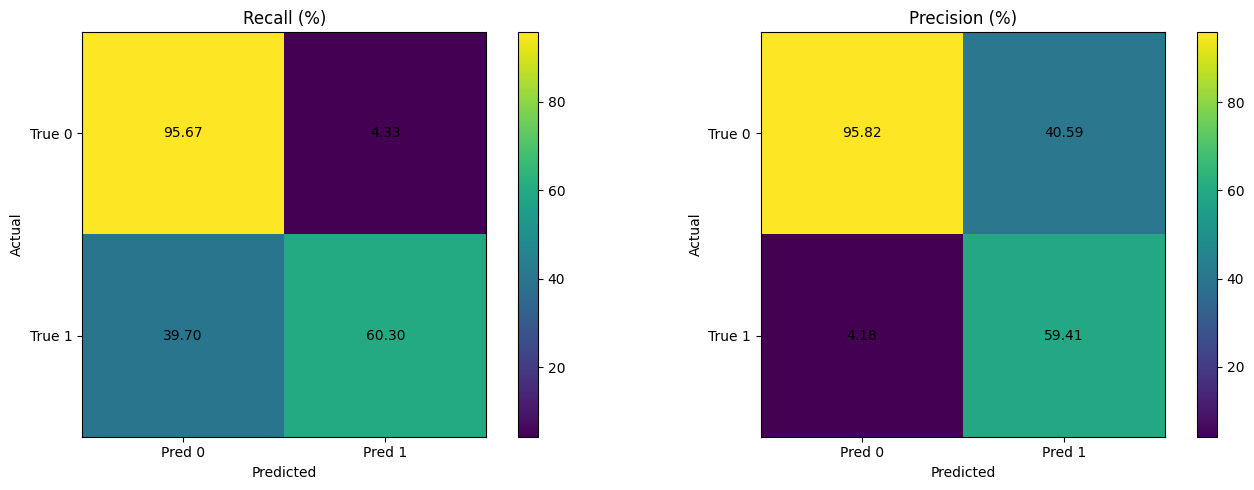

In [74]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_data["label"], val_data["pred"])

# Row-normalized (per true class)
cm_recall = np.round(cm / cm.sum(axis=1, keepdims=True) * 100, 2)

# Column-normalized (per predicted class)
cm_precision = np.round(cm / cm.sum(axis=0, keepdims=True) * 100, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Recall Matrix ----
im1 = axes[0].imshow(cm_recall)
axes[0].set_title("Recall (%)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Pred 0", "Pred 1"])
axes[0].set_yticklabels(["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm_recall[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im1, ax=axes[0])


# ---- Precision Matrix ----
im2 = axes[1].imshow(cm_precision)
axes[1].set_title("Precision (%)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Pred 0", "Pred 1"])
axes[1].set_yticklabels(["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{cm_precision[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

,Unbalanced power relations,Shallow solution,Presupposition,Authority voice,Metaphor,Compassion,Poorer the merrier
0,142,36,62,38,52,106,11


,Unbalanced power relations,Shallow solution,Presupposition,Authority voice,Metaphor,Compassion,Poorer the merrier
0,35.21,33.33,40.32,39.47,30.77,32.08,27.27


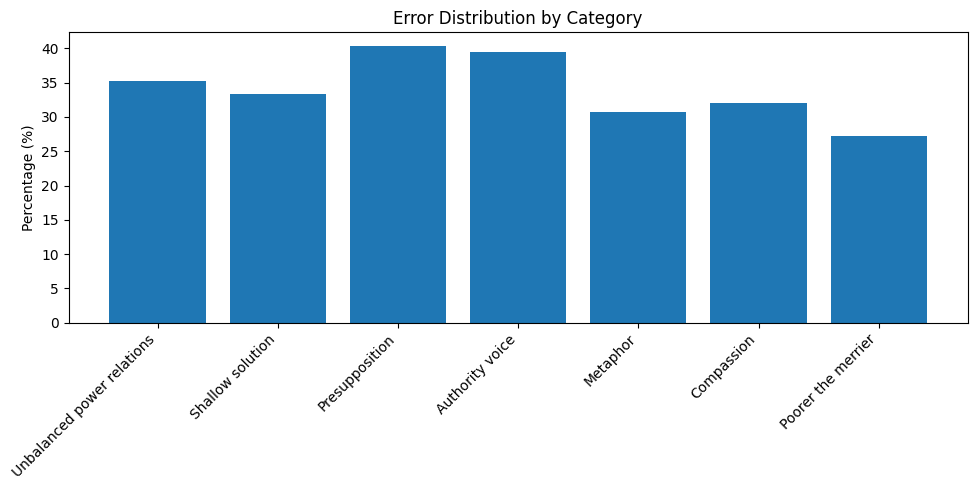

In [75]:
import ast 

categories = ["Unbalanced power relations", "Shallow solution", "Presupposition", "Authority voice", "Metaphor", "Compassion", "Poorer the merrier"]

# We try to group incorrectly predicted values based on their PCL type tags 
RAW_VAL_DATA_PATH = "../data/dev_semeval_parids-labels.csv"
raw_val = pd.read_csv(RAW_VAL_DATA_PATH)
raw_val["label"] = raw_val.label.apply(ast.literal_eval)

category_counts = np.array(raw_val["label"].tolist()).sum(axis=0).reshape(1,-1)
display(pd.DataFrame(category_counts, columns=categories))

incorrect_preds = raw_val[raw_val["par_id"].isin(wrong_results["id"])]
arr = np.array(incorrect_preds["label"].tolist())
normalised_col_sum = np.round(arr.sum(axis=0).reshape(1,-1) / category_counts * 100, 2)


wrong_categories = pd.DataFrame(normalised_col_sum, columns=categories)

display(wrong_categories)

plt.figure(figsize=(10, 5))
plt.bar(wrong_categories.columns, wrong_categories.iloc[0].values)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.title("Error Distribution by Category")

plt.tight_layout()
plt.show()